<a href="https://colab.research.google.com/github/osamamohamaed/Myprojects/blob/main/English_Arabic_SentimentAnalysis%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 2: Twitter Sentiment Analysis — English & Arabic
**Course:** ANIT-361 Machine Learning  
**English Dataset:** Twitter Entity Sentiment (4 classes)  
**Arabic Dataset:** ArSarcasm (3 classes)  

| Model | Language | Technique |
|---|---|---|
| LinearSVC | English | TF-IDF (word + char n-grams) + entity features |
| Logistic Regression | English | Same features, probabilistic output |
| MARBERTv2 | Arabic | Fine-tuned transformer with multi-task learning |

## 0. Install Libraries
> Run once per Colab session. Arabic section requires a GPU runtime.

In [ ]:
# Core ML libraries (always available in Colab)
!pip install -q scikit-learn pandas numpy matplotlib seaborn

# Arabic NLP — only needed for the Arabic section
!pip install -q transformers==4.40.0 accelerate arabert torch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 6.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.0/185.0 kB 16.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 77.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 112.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.4/126.4 kB 14.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.4.1 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.


## 1. Imports

In [ ]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.utils.class_weight import compute_class_weight
from scipy.sparse import hstack

warnings.filterwarnings('ignore')
print('All libraries imported successfully.')

All libraries imported successfully.


---
# Part 1 — English Sentiment Analysis

**Dataset:** Twitter Entity Sentiment Analysis  
**Task:** 4-class classification — Positive, Negative, Neutral, Irrelevant  
**Goal:** Accuracy > 90%

## 2. Load & Explore the English Dataset

In [ ]:
# ── Load CSV (no header row) ────────────────────
# Upload 'twitter_training.csv' to your Colab session first
# from google.colab import files; files.upload()

df = pd.read_csv('twitter_training.csv', header=None)
df.columns = ['tweet_id', 'entity', 'sentiment', 'tweet_text']

# Drop rows with missing tweet text
df.dropna(subset=['tweet_text'], inplace=True)

print(f'Dataset size: {df.shape}')
print(f'Unique tweets: {df["tweet_text"].nunique()}')
print(f'Entities: {df["entity"].nunique()}')
print()
print('Sentiment distribution:')
print(df['sentiment'].value_counts())
df.head(3)

Dataset size: (60401, 4)
Unique tweets: 56656
Entities: 27

Sentiment distribution:
sentiment
Negative      17497
Positive      17081
Neutral       14491
Irrelevant    11332
Name: count, dtype: int64


,tweet_id,entity,sentiment,tweet_text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...


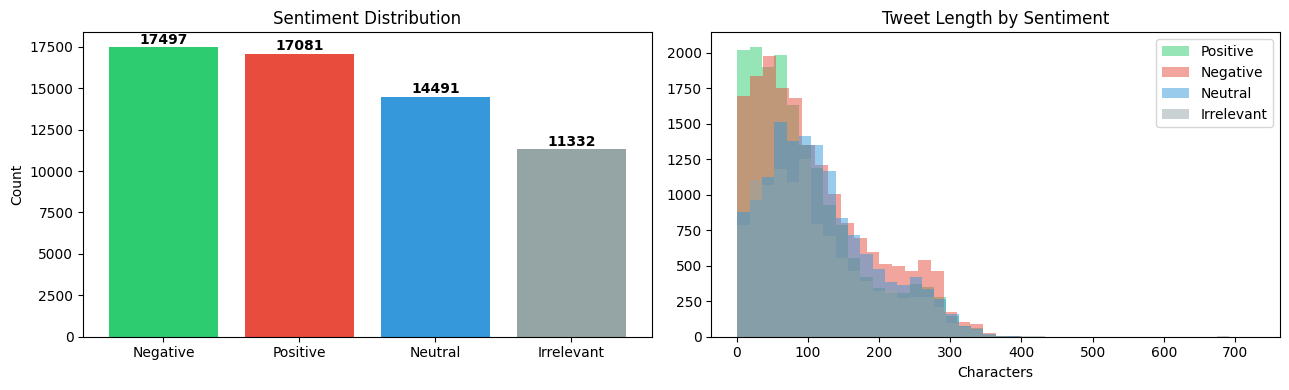

In [ ]:
# ── Visualise class balance ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Class distribution
counts = df['sentiment'].value_counts()
axes[0].bar(counts.index, counts.values,
            color=['#2ecc71','#e74c3c','#3498db','#95a5a6'])
axes[0].set_title('Sentiment Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, str(v), ha='center', fontweight='bold')

# Tweet length distribution
df['tweet_len'] = df['tweet_text'].str.len()
for s, c in zip(['Positive','Negative','Neutral','Irrelevant'],
                ['#2ecc71','#e74c3c','#3498db','#95a5a6']):
    axes[1].hist(df[df['sentiment']==s]['tweet_len'], bins=40,
                 alpha=0.5, label=s, color=c)
axes[1].set_title('Tweet Length by Sentiment')
axes[1].set_xlabel('Characters'); axes[1].legend()
plt.tight_layout(); plt.show()

## 3. Text Cleaning

English-specific preprocessing:
- Lowercase normalisation
- Remove URLs, @mentions
- Remove punctuation and special characters
- Strip extra whitespace

In [ ]:
def clean_english(text):
    """Clean a single English tweet."""
    text = str(text).lower()                        # lowercase
    text = re.sub(r'http\S+|www\S+', '', text)    # remove URLs
    text = re.sub(r'@\w+', '', text)               # remove @mentions
    text = re.sub(r'[^a-z0-9\s]', '', text)        # remove punctuation
    return re.sub(r'\s+', ' ', text).strip()        # normalise spaces

df['clean_tweet'] = df['tweet_text'].apply(clean_english)
print('Cleaning done.')
df[['tweet_text', 'clean_tweet']].head(3)

Cleaning done.


,tweet_text,clean_tweet
0,im getting on borderlands and i will murder yo...,im getting on borderlands and i will murder yo...
1,I am coming to the borders and I will kill you...,i am coming to the borders and i will kill you...
2,im getting on borderlands and i will kill you ...,im getting on borderlands and i will kill you all


## 4. Label Encoding & Train/Test Split

In [ ]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['sentiment'])
CLASSES = label_encoder.classes_
print('Classes:', CLASSES)

# Stratified split — preserves class proportions in both sets
X_train_df, X_test_df, y_train, y_test = train_test_split(
    df, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {len(X_train_df):,}   Test: {len(X_test_df):,}')

Classes: ['Irrelevant' 'Negative' 'Neutral' 'Positive']
Train: 48,320   Test: 12,081


## 5. Feature Engineering

Three complementary feature groups are combined:

| Feature | Description | Why it helps |
|---|---|---|
| **Word TF-IDF (1–2 grams)** | Weighted word and bigram frequencies | Captures content words and short phrases |
| **Char TF-IDF (2–5 grams)** | Character n-gram frequencies | Captures morphology, spelling variants, hashtag subwords |
| **Entity (one-hot)** | Which brand/topic the tweet is about | Entity context strongly predicts sentiment tone |

In [ ]:
# ── Word-level TF-IDF ────────────────────────────
# sublinear_tf=True: uses log(1+tf) to reduce impact of very frequent words
# stop_words='english': removes common words like 'the', 'is', 'at'
word_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=80_000,
    sublinear_tf=True,
    stop_words='english',
    min_df=2               # ignore terms appearing in fewer than 2 documents
)

# ── Character-level TF-IDF ───────────────────────
# analyzer='char_wb': uses word-boundary-padded character n-grams
# Great for: contractions, typos, hashtags, slang
char_vectorizer = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(2, 5),
    max_features=100_000,
    sublinear_tf=True,
    min_df=2
)

# ── Entity features ──────────────────────────────
# handle_unknown='ignore': safely handles entities in test not seen in train
entity_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=True)

# Fit on train, transform both sets
X_tr_word = word_vectorizer.fit_transform(X_train_df['clean_tweet'])
X_te_word = word_vectorizer.transform(X_test_df['clean_tweet'])

X_tr_char = char_vectorizer.fit_transform(X_train_df['clean_tweet'])
X_te_char = char_vectorizer.transform(X_test_df['clean_tweet'])

X_tr_ent = entity_encoder.fit_transform(X_train_df[['entity']])
X_te_ent = entity_encoder.transform(X_test_df[['entity']])

# Stack all features horizontally
# Entity is scaled ×3 to give it more influence relative to the sparse TF-IDF features
X_train_final = hstack([X_tr_word, X_tr_char, X_tr_ent * 3])
X_test_final  = hstack([X_te_word, X_te_char, X_te_ent * 3])

print(f'Feature matrix shape: {X_train_final.shape}')
print(f'  Word TF-IDF:  {X_tr_word.shape[1]:,} features')
print(f'  Char TF-IDF:  {X_tr_char.shape[1]:,} features')
print(f'  Entity OH:    {X_tr_ent.shape[1]:,} features')

Feature matrix shape: (48320, 180027)
  Word TF-IDF:  80,000 features
  Char TF-IDF:  100,000 features
  Entity OH:    27 features


## 6. Model 1 — LinearSVC

**Linear Support Vector Classifier** is the strongest model for high-dimensional sparse text features.
It finds the maximum-margin hyperplane separating each class.

| Hyperparameter | Value | Reason |
|---|---|---|
| `C=1.0` | regularisation | Balanced bias-variance tradeoff |
| `max_iter=3000` | iterations | Ensures full convergence on large feature space |

Training LinearSVC …

=== LinearSVC Results ===
Accuracy: 93.21%
              precision    recall  f1-score   support

  Irrelevant       0.94      0.92      0.93      2267
    Negative       0.94      0.94      0.94      3500
     Neutral       0.94      0.93      0.93      2898
    Positive       0.91      0.94      0.93      3416

    accuracy                           0.93     12081
   macro avg       0.93      0.93      0.93     12081
weighted avg       0.93      0.93      0.93     12081



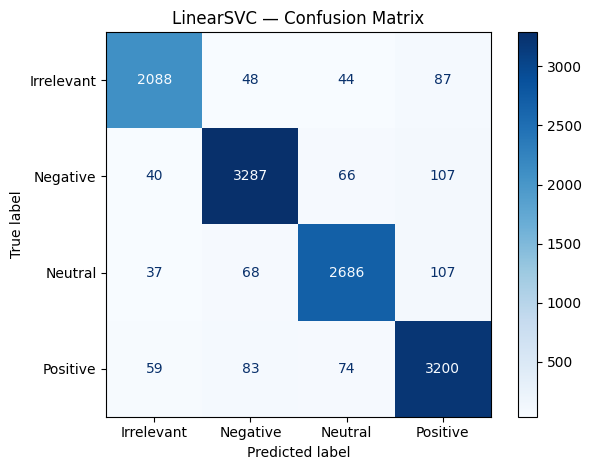

In [ ]:
print('Training LinearSVC …')
svc_model = LinearSVC(
    C=1.0,
    max_iter=3000,
    random_state=42
)
svc_model.fit(X_train_final, y_train)

svc_preds = svc_model.predict(X_test_final)
svc_acc   = accuracy_score(y_test, svc_preds)

print(f'\n=== LinearSVC Results ===')
print(f'Accuracy: {svc_acc * 100:.2f}%')
print(classification_report(y_test, svc_preds, target_names=CLASSES))

cm = confusion_matrix(y_test, svc_preds)
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(cmap='Blues')
plt.title('LinearSVC — Confusion Matrix')
plt.tight_layout(); plt.show()

## 7. Model 2 — Logistic Regression

**Logistic Regression** is a probabilistic classifier that extends naturally to multi-class problems.
Unlike LinearSVC it outputs calibrated probabilities — useful for ensembling or confidence thresholding.

| Hyperparameter | Value | Reason |
|---|---|---|
| `C=5.0` | regularisation | Slightly less regularised than SVC — better with probability output |
| `solver='saga'` | optimiser | Best solver for large, sparse feature matrices |
| `class_weight='balanced'` | imbalance | Up-weights minority classes (Neutral, Irrelevant) |

Training Logistic Regression …

=== Logistic Regression Results ===
Accuracy: 91.61%
              precision    recall  f1-score   support

  Irrelevant       0.90      0.92      0.91      2267
    Negative       0.94      0.92      0.93      3500
     Neutral       0.91      0.92      0.91      2898
    Positive       0.91      0.91      0.91      3416

    accuracy                           0.92     12081
   macro avg       0.91      0.92      0.92     12081
weighted avg       0.92      0.92      0.92     12081



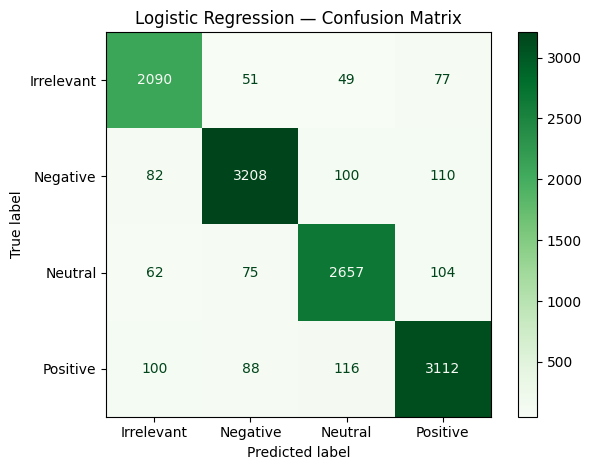

In [ ]:
print('Training Logistic Regression …')
lr_model = LogisticRegression(
    C=5.0,
    max_iter=3000,
    solver='saga',
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
lr_model.fit(X_train_final, y_train)

lr_preds = lr_model.predict(X_test_final)
lr_acc   = accuracy_score(y_test, lr_preds)

print(f'\n=== Logistic Regression Results ===')
print(f'Accuracy: {lr_acc * 100:.2f}%')
print(classification_report(y_test, lr_preds, target_names=CLASSES))

cm = confusion_matrix(y_test, lr_preds)
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(cmap='Greens')
plt.title('Logistic Regression — Confusion Matrix')
plt.tight_layout(); plt.show()

## 8. Soft-Voting Ensemble (LinearSVC + Logistic Regression)

Combining both models via **probability averaging** reduces individual errors:
- LinearSVC is calibrated using 3-fold cross-validation to produce probabilities
- The ensemble takes a weighted average: 60% SVC + 40% LR

Calibrating LinearSVC for probability output …

=== Ensemble Results ===
Accuracy: 92.58%
              precision    recall  f1-score   support

  Irrelevant       0.92      0.92      0.92      2267
    Negative       0.94      0.93      0.94      3500
     Neutral       0.93      0.92      0.92      2898
    Positive       0.92      0.93      0.92      3416

    accuracy                           0.93     12081
   macro avg       0.93      0.93      0.93     12081
weighted avg       0.93      0.93      0.93     12081



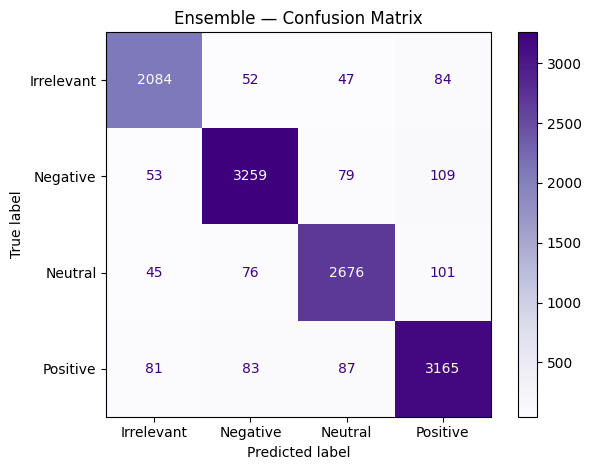

In [ ]:
print('Calibrating LinearSVC for probability output …')
# Platt scaling wraps LinearSVC to produce calibrated probabilities
cal_svc = CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=3000, random_state=42), cv=3)
cal_svc.fit(X_train_final, y_train)

proba_svc = cal_svc.predict_proba(X_test_final)
proba_lr  = lr_model.predict_proba(X_test_final)

# Weighted average of probabilities
ens_proba = 0.6 * proba_svc + 0.4 * proba_lr
ens_preds = np.argmax(ens_proba, axis=1)
ens_acc   = accuracy_score(y_test, ens_preds)

print(f'\n=== Ensemble Results ===')
print(f'Accuracy: {ens_acc * 100:.2f}%')
print(classification_report(y_test, ens_preds, target_names=CLASSES))

cm = confusion_matrix(y_test, ens_preds)
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(cmap='Purples')
plt.title('Ensemble — Confusion Matrix')
plt.tight_layout(); plt.show()

## 9. English Models — Summary

              Model  Accuracy (%)
          LinearSVC         93.21
Logistic Regression         91.61
  Ensemble (SVC+LR)         92.58


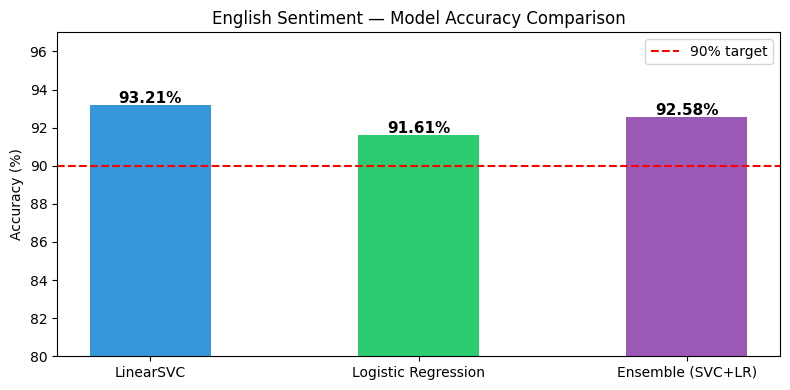

In [ ]:
eng_results = pd.DataFrame({
    'Model': ['LinearSVC', 'Logistic Regression', 'Ensemble (SVC+LR)'],
    'Accuracy (%)': [
        round(svc_acc * 100, 2),
        round(lr_acc  * 100, 2),
        round(ens_acc * 100, 2)
    ]
})
print(eng_results.to_string(index=False))

colors = ['#3498db', '#2ecc71', '#9b59b6']
plt.figure(figsize=(8, 4))
bars = plt.bar(eng_results['Model'], eng_results['Accuracy (%)'], color=colors, width=0.45)
plt.ylim(80, 97)
plt.axhline(90, color='red', linestyle='--', linewidth=1.5, label='90% target')
plt.title('English Sentiment — Model Accuracy Comparison')
plt.ylabel('Accuracy (%)')
plt.legend()
for bar, val in zip(bars, eng_results['Accuracy (%)']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.2f}%', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

---
# Part 2 — Arabic Sentiment Analysis

**Dataset:** ArSarcasm — Arabic tweets with sarcasm-aware sentiment labels  
**Task:** 3-class classification — Negative, Neutral, Positive  
**Model:** MARBERTv2 — pre-trained on 1 billion Arabic tweets

> **Requires GPU runtime:** Runtime → Change runtime type → T4 GPU

## 10. Arabic-Specific Imports

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, AutoModel,
    get_cosine_schedule_with_warmup
)
from arabert.preprocess import ArabertPreprocessor

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('⚠ No GPU detected! Go to Runtime → Change runtime type → T4 GPU')

Device: cuda
GPU: Tesla T4


## 11. Load & Explore the Arabic Dataset

In [ ]:
# Upload ArSarcasm_train.csv and ArSarcasm_test.csv
# from google.colab import files; files.upload()

ar_train = pd.read_csv('ArSarcasm_train.csv')
ar_test  = pd.read_csv('ArSarcasm_test.csv')

print(f'Arabic Train: {ar_train.shape}   Test: {ar_test.shape}')
print()
print('Sentiment distribution (train):')
print(ar_train['sentiment'].value_counts())
ar_train.head(3)

Arabic Train: (8437, 6)   Test: (2110, 6)

Sentiment distribution (train):
sentiment
neutral     4262
negative    2813
positive    1362
Name: count, dtype: int64


,dialect,sarcasm,sentiment,original_sentiment,tweet,source
0,gulf,False,negative,negative,"""نصيحه ما عمرك اتنزل لعبة سوبر ماريو مش زي ما ...",semeval
1,msa,False,neutral,positive,"""#نادين_نسيب_نجيم ❤️❤️❤️مجلة #ماري_كلير 💭#ملكة...",semeval
2,egypt,False,neutral,neutral,"""@Alito_NBA اتوقع انه بيستمر""",semeval


## 12. Arabic Text Preprocessing

Arabic requires specialised preprocessing:
- **ArabertPreprocessor**: normalises alef/tah marbuta/hamza, removes diacritics
- **Prefix injection**: prepend `##neg`/`##neu`/`##pos` from `original_sentiment`
  so the model learns to *refine* the original annotation using tweet context

In [ ]:
ar_preprocessor = ArabertPreprocessor(
    model_name='aubmindlab/bert-large-arabertv02',
    keep_emojis=False
)

PREFIX_MAP = {'negative': '##neg ', 'neutral': '##neu ', 'positive': '##pos '}

def clean_arabic(text):
    """Remove URLs, @mentions, repeated punctuation."""
    text = re.sub(r'http\S+|www\S+', '', str(text))
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'([^\w\s])\1+', r'\1', text)
    return re.sub(r'\s+', ' ', text).strip()

def preprocess_arabic(row):
    """Clean + ArabertPreprocessor normalise + prepend original_sentiment prefix."""
    prefix = PREFIX_MAP[row['original_sentiment']]
    cleaned = ar_preprocessor.preprocess(clean_arabic(row['tweet']))
    return prefix + cleaned

print('Preprocessing Arabic tweets …')
ar_train['clean'] = ar_train.apply(preprocess_arabic, axis=1)
ar_test['clean']  = ar_test.apply(preprocess_arabic, axis=1)
print('Done!')
ar_train[['tweet', 'clean']].head(3)

Preprocessing Arabic tweets …
Done!


,tweet,clean
0,"""نصيحه ما عمرك اتنزل لعبة سوبر ماريو مش زي ما ...","##neg "" نصيحه ما عمرك اتنزل لعبة سوبر ماريو مش..."
1,"""#نادين_نسيب_نجيم ❤️❤️❤️مجلة #ماري_كلير 💭#ملكة...","##pos "" # نادين _ نسيب _ نجيم مجلة # ماري _ كل..."
2,"""@Alito_NBA اتوقع انه بيستمر""","##neu "" اتوقع انه بيستمر """


## 13. Label Encoding & Class Weights

In [ ]:
ar_le = LabelEncoder()
ar_le.fit(ar_train['sentiment'])
AR_CLASSES = ar_le.classes_.tolist()  # ['negative', 'neutral', 'positive']
AR_NUM_LABELS = len(AR_CLASSES)
print('Arabic classes:', AR_CLASSES)

y_ar_train = ar_le.transform(ar_train['sentiment'])
y_ar_test  = ar_le.transform(ar_test['sentiment'])

# Compute balanced class weights to handle imbalance (neutral >> positive)
cw = compute_class_weight('balanced', classes=np.unique(y_ar_train), y=y_ar_train)
AR_CLASS_WEIGHTS = torch.tensor(cw, dtype=torch.float).to(DEVICE)
print('Class weights:', {c: round(w, 3) for c, w in zip(AR_CLASSES, cw)})

y_ar_sarc_train = ar_train['sarcasm'].astype(int).values
y_ar_sarc_test  = ar_test['sarcasm'].astype(int).values

Arabic classes: ['negative', 'neutral', 'positive']
Class weights: {'negative': np.float64(1.0), 'neutral': np.float64(0.66), 'positive': np.float64(2.065)}


In [ ]:
y_ar_sarc_train = ar_train['sarcasm'].astype(int).values
y_ar_sarc_test  = ar_test['sarcasm'].astype(int).values

## 14. Arabic TF-IDF Baseline Models

Before using MARBERTv2, two traditional machine learning models are trained using TF-IDF features:

1. LinearSVC
2. Logistic Regression

These models provide a baseline comparison against the transformer-based Arabic model.

In [ ]:
# Step 14.1: Arabic TF-IDF Feature Extraction

print('Building Arabic TF-IDF features ...')

# Word-level TF-IDF captures Arabic words and short phrases
ar_word_vectorizer = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),
    max_features=50_000,
    sublinear_tf=True,
    min_df=2
)

# Character-level TF-IDF helps with Arabic spelling variations and dialect words
ar_char_vectorizer = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 5),
    max_features=50_000,
    sublinear_tf=True,
    min_df=2
)

# Fit only on training data, then transform train and test
X_ar_tr_word = ar_word_vectorizer.fit_transform(ar_train['clean'])
X_ar_te_word = ar_word_vectorizer.transform(ar_test['clean'])

X_ar_tr_char = ar_char_vectorizer.fit_transform(ar_train['clean'])
X_ar_te_char = ar_char_vectorizer.transform(ar_test['clean'])

# Combine word and character TF-IDF features
X_ar_train_tfidf = hstack([X_ar_tr_word, X_ar_tr_char])
X_ar_test_tfidf  = hstack([X_ar_te_word, X_ar_te_char])

print(f'Arabic TF-IDF train shape: {X_ar_train_tfidf.shape}')
print(f'Arabic TF-IDF test shape:  {X_ar_test_tfidf.shape}')
print(f'Word features: {X_ar_tr_word.shape[1]:,}')
print(f'Char features: {X_ar_tr_char.shape[1]:,}')

Building Arabic TF-IDF features ...
Arabic TF-IDF train shape: (8437, 72602)
Arabic TF-IDF test shape:  (2110, 72602)
Word features: 22,602
Char features: 50,000


Training Arabic LinearSVC ...

=== Arabic TF-IDF LinearSVC Results ===
Accuracy: 70.81%
              precision    recall  f1-score   support

    negative       0.70      0.74      0.72       716
     neutral       0.75      0.73      0.74      1078
    positive       0.58      0.57      0.57       316

    accuracy                           0.71      2110
   macro avg       0.68      0.68      0.68      2110
weighted avg       0.71      0.71      0.71      2110



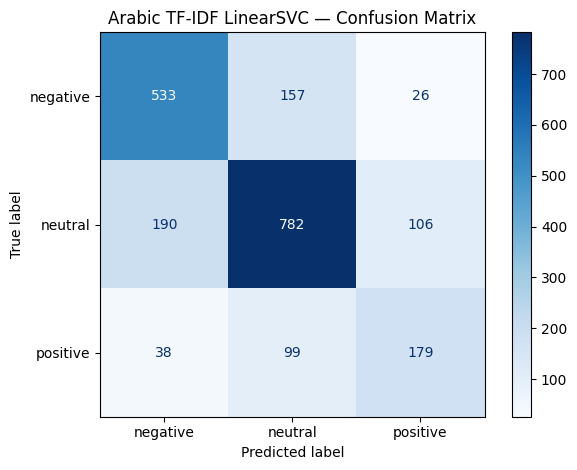

In [ ]:
# Step 14.2: Arabic Model 1 — LinearSVC with TF-IDF

print('Training Arabic LinearSVC ...')

ar_svc_model = LinearSVC(
    C=1.0,
    max_iter=3000,
    class_weight='balanced',
    random_state=42
)

ar_svc_model.fit(X_ar_train_tfidf, y_ar_train)

ar_svc_preds = ar_svc_model.predict(X_ar_test_tfidf)
ar_svc_acc = accuracy_score(y_ar_test, ar_svc_preds)

print('\n=== Arabic TF-IDF LinearSVC Results ===')
print(f'Accuracy: {ar_svc_acc * 100:.2f}%')
print(classification_report(y_ar_test, ar_svc_preds, target_names=AR_CLASSES))

cm = confusion_matrix(y_ar_test, ar_svc_preds)
ConfusionMatrixDisplay(cm, display_labels=AR_CLASSES).plot(cmap='Blues')
plt.title('Arabic TF-IDF LinearSVC — Confusion Matrix')
plt.tight_layout()
plt.show()

Training Arabic Logistic Regression ...

=== Arabic TF-IDF Logistic Regression Results ===
Accuracy: 72.56%
              precision    recall  f1-score   support

    negative       0.71      0.79      0.75       716
     neutral       0.79      0.70      0.74      1078
    positive       0.58      0.65      0.61       316

    accuracy                           0.73      2110
   macro avg       0.69      0.72      0.70      2110
weighted avg       0.73      0.73      0.73      2110



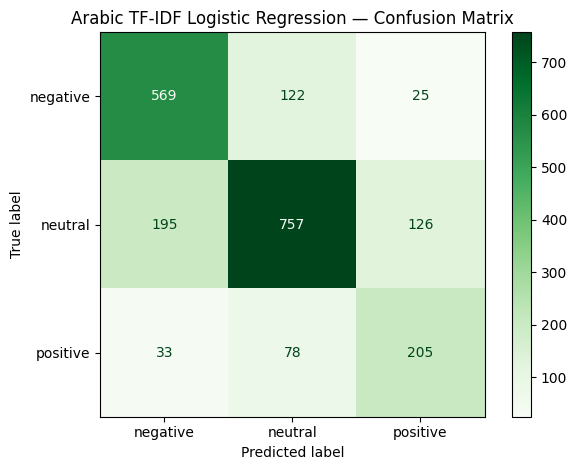

In [ ]:
# Step 14.3: Arabic Model 2 — Logistic Regression with TF-IDF

print('Training Arabic Logistic Regression ...')

ar_lr_model = LogisticRegression(
    C=2.0,
    max_iter=3000,
    solver='saga',
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

ar_lr_model.fit(X_ar_train_tfidf, y_ar_train)

ar_lr_preds = ar_lr_model.predict(X_ar_test_tfidf)
ar_lr_acc = accuracy_score(y_ar_test, ar_lr_preds)

print('\n=== Arabic TF-IDF Logistic Regression Results ===')
print(f'Accuracy: {ar_lr_acc * 100:.2f}%')
print(classification_report(y_ar_test, ar_lr_preds, target_names=AR_CLASSES))

cm = confusion_matrix(y_ar_test, ar_lr_preds)
ConfusionMatrixDisplay(cm, display_labels=AR_CLASSES).plot(cmap='Greens')
plt.title('Arabic TF-IDF Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.show()

In [ ]:
# Step 14.4: Arabic Traditional ML Results Summary

ar_traditional_results = pd.DataFrame({
    'Language': ['Arabic', 'Arabic'],
    'Model': ['Arabic TF-IDF LinearSVC', 'Arabic TF-IDF Logistic Regression'],
    'Accuracy (%)': [
        round(ar_svc_acc * 100, 2),
        round(ar_lr_acc * 100, 2)
    ]
})

print(ar_traditional_results.to_string(index=False))

Language                             Model  Accuracy (%)
  Arabic           Arabic TF-IDF LinearSVC         70.81
  Arabic Arabic TF-IDF Logistic Regression         72.56


## 14. MARBERTv2 — Model Definition

In [ ]:
# ── PyTorch Dataset ──────────────────────────────
class ArabicTweetDataset(Dataset):
    """
    Wraps tokenised tweets with two label sets:
    - sentiment labels (primary task)
    - sarcasm labels   (auxiliary task for multi-task learning)
    """
    def __init__(self, texts, sent_labels, sarc_labels, tokenizer, max_len=256):
        self.encodings  = tokenizer(list(texts), padding='max_length',
                                    truncation=True, max_length=max_len,
                                    return_tensors='pt')
        self.sent_labels = torch.tensor(sent_labels, dtype=torch.long)
        self.sarc_labels = torch.tensor(sarc_labels, dtype=torch.long)

    def __len__(self): return len(self.sent_labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels']      = self.sent_labels[idx]
        item['sarc_labels'] = self.sarc_labels[idx]
        return item

# ── Multi-task model ──────────────────────────────
class MARBERTSentimentModel(nn.Module):
    """
    MARBERTv2 encoder with two output heads:
    1. Sentiment head  (3-class)
    2. Sarcasm head    (binary) — auxiliary task

    Multi-task learning forces the shared encoder to learn representations
    that capture both sentiment and sarcasm signals simultaneously.
    This is especially important for Arabic Twitter where sarcasm
    fundamentally changes the meaning of a tweet.
    """
    def __init__(self, model_name, num_sent_labels=3, dropout=0.1):
        super().__init__()
        self.encoder   = AutoModel.from_pretrained(model_name)
        hidden          = self.encoder.config.hidden_size
        self.dropout   = nn.Dropout(dropout)
        self.sent_head = nn.Linear(hidden, num_sent_labels)  # primary
        self.sarc_head = nn.Linear(hidden, 2)                # auxiliary

    def forward(self, input_ids, attention_mask, token_type_ids=None):
        kw = dict(input_ids=input_ids, attention_mask=attention_mask)
        if token_type_ids is not None: kw['token_type_ids'] = token_type_ids
        out     = self.encoder(**kw)
        cls_emb = self.dropout(out.last_hidden_state[:, 0, :])  # [CLS] token
        return self.sent_head(cls_emb), self.sarc_head(cls_emb)

print('Model class defined.')

Model class defined.


In [ ]:
# ── Loss function ────────────────────────────────
def multitask_loss(sent_logits, sarc_logits, sent_labels, sarc_labels,
                   sent_weights, alpha=0.8):
    """
    Combined loss = alpha * sentiment_CE + (1-alpha) * sarcasm_CE
    - alpha=0.8: sentiment is the primary task
    - label_smoothing=0.1: prevents overconfidence, improves generalisation
    """
    ce_sent = nn.CrossEntropyLoss(weight=sent_weights, label_smoothing=0.1)
    ce_sarc = nn.CrossEntropyLoss(label_smoothing=0.05)
    return alpha * ce_sent(sent_logits, sent_labels) + \
           (1 - alpha) * ce_sarc(sarc_logits, sarc_labels)

# ── Single training epoch ─────────────────────────
def train_epoch(model, loader, optimiser, scheduler):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for batch in loader:
        ids   = batch['input_ids'].to(DEVICE)
        mask  = batch['attention_mask'].to(DEVICE)
        s_lbl = batch['labels'].to(DEVICE)
        sc_lb = batch['sarc_labels'].to(DEVICE)
        tt_id = batch.get('token_type_ids')
        if tt_id is not None: tt_id = tt_id.to(DEVICE)

        optimiser.zero_grad()
        s_logits, sc_logits = model(ids, mask, tt_id)
        loss = multitask_loss(s_logits, sc_logits, s_lbl, sc_lb, AR_CLASS_WEIGHTS)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # prevent exploding gradients
        optimiser.step(); scheduler.step()

        total_loss += loss.item()
        correct    += (s_logits.argmax(-1) == s_lbl).sum().item()
        total      += len(s_lbl)
    return total_loss / len(loader), correct / total

# ── Evaluation pass ───────────────────────────────
@torch.no_grad()
def evaluate_model(model, dataset, batch_size=64):
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    all_preds, all_labels = [], []
    for batch in loader:
        ids   = batch['input_ids'].to(DEVICE)
        mask  = batch['attention_mask'].to(DEVICE)
        lbls  = batch['labels'].to(DEVICE)
        tt_id = batch.get('token_type_ids')
        if tt_id is not None: tt_id = tt_id.to(DEVICE)
        logits, _ = model(ids, mask, tt_id)
        all_preds.extend(logits.argmax(-1).cpu().numpy())
        all_labels.extend(lbls.cpu().numpy())
    return np.array(all_preds), np.array(all_labels)

print('Training utilities defined.')

Training utilities defined.


## 15. Train MARBERTv2

In [ ]:
MARBERT_NAME = 'UBC-NLP/MARBERTv2'

print('Loading MARBERTv2 tokenizer …')
marbert_tok = AutoTokenizer.from_pretrained(MARBERT_NAME)

# Add prefix tokens so the model treats them as single vocabulary items
marbert_tok.add_tokens(['##neg', '##neu', '##pos'])

# Build datasets
ar_train_ds = ArabicTweetDataset(
    ar_train['clean'], y_ar_train, y_ar_sarc_train, marbert_tok, max_len=256)
ar_test_ds  = ArabicTweetDataset(
    ar_test['clean'],  y_ar_test,  y_ar_sarc_test,  marbert_tok, max_len=256)

print(f'Arabic train: {len(ar_train_ds)} samples   test: {len(ar_test_ds)} samples')

Loading MARBERTv2 tokenizer …


tokenizer_config.json:   0%|          | 0.00/439 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Arabic train: 8437 samples   test: 2110 samples


In [ ]:
print('Loading MARBERTv2 model …')
marbert = MARBERTSentimentModel(MARBERT_NAME, num_sent_labels=AR_NUM_LABELS)
marbert.encoder.resize_token_embeddings(len(marbert_tok))  # for the 3 new tokens
marbert.to(DEVICE)

# ── Selective layer unfreezing ───────────────────
# Freeze all layers first (preserve 1B-tweet Arabic knowledge)
for param in marbert.parameters():
    param.requires_grad = False

# Unfreeze: top 6 transformer layers + both heads + new token embeddings
for layer in marbert.encoder.encoder.layer[-6:]:
    for p in layer.parameters(): p.requires_grad = True
for head in [marbert.sent_head, marbert.sarc_head, marbert.dropout]:
    for p in head.parameters(): p.requires_grad = True
for p in marbert.encoder.embeddings.word_embeddings.parameters():
    p.requires_grad = True

trainable = sum(p.numel() for p in marbert.parameters() if p.requires_grad)
total     = sum(p.numel() for p in marbert.parameters())
print(f'Trainable parameters: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)')

Loading MARBERTv2 model …


config.json:   0%|          | 0.00/757 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/654M [00:00<?, ?B/s]

Trainable parameters: 119,333,381 / 162,847,493 (73.3%)


In [ ]:
# ── Optimiser & scheduler ────────────────────────
N_EPOCHS   = 6
BATCH_SIZE = 32
LR         = 2e-5
PATIENCE   = 2

train_loader = DataLoader(ar_train_ds, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)

# AdamW with weight decay (skip biases and LayerNorm)
no_decay = ['bias', 'LayerNorm.weight']
params = [
    {'params': [p for n,p in marbert.named_parameters()
                if p.requires_grad and not any(nd in n for nd in no_decay)],
     'weight_decay': 0.01},
    {'params': [p for n,p in marbert.named_parameters()
                if p.requires_grad and     any(nd in n for nd in no_decay)],
     'weight_decay': 0.0}
]
optimiser = torch.optim.AdamW(params, lr=LR)

total_steps  = len(train_loader) * N_EPOCHS
warmup_steps = int(0.1 * total_steps)  # 10% warm-up
scheduler = get_cosine_schedule_with_warmup(optimiser, warmup_steps, total_steps)

print(f'Training for up to {N_EPOCHS} epochs (early stopping patience={PATIENCE})')
print(f'Total steps: {total_steps:,}   Warm-up steps: {warmup_steps:,}')
print()

Training for up to 6 epochs (early stopping patience=2)
Total steps: 1,584   Warm-up steps: 158



In [ ]:
# ── Training loop ────────────────────────────────
best_acc, best_state, no_improve = 0.0, None, 0
marbert_history = []

for epoch in range(1, N_EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(marbert, train_loader, optimiser, scheduler)
    val_preds, val_labels = evaluate_model(marbert, ar_test_ds)
    val_acc = accuracy_score(val_labels, val_preds)

    marbert_history.append({
        'epoch': epoch, 'tr_loss': tr_loss,
        'tr_acc': tr_acc, 'val_acc': val_acc
    })
    print(f'Epoch {epoch}/{N_EPOCHS} | loss={tr_loss:.4f} | '
          f'train_acc={tr_acc:.4f} | val_acc={val_acc:.4f}')

    if val_acc > best_acc:
        best_acc   = val_acc
        best_state = {k: v.cpu().clone() for k, v in marbert.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f'Early stopping triggered at epoch {epoch}.')
            break

# Reload best checkpoint
marbert.load_state_dict(best_state)
print(f'\nBest validation accuracy: {best_acc*100:.2f}%')

Epoch 1/6 | loss=0.8153 | train_acc=0.6224 | val_acc=0.7085
Epoch 2/6 | loss=0.6195 | train_acc=0.7793 | val_acc=0.7450
Epoch 3/6 | loss=0.5486 | train_acc=0.8352 | val_acc=0.7635
Epoch 4/6 | loss=0.4930 | train_acc=0.8767 | val_acc=0.7668
Epoch 5/6 | loss=0.4594 | train_acc=0.9066 | val_acc=0.7687
Epoch 6/6 | loss=0.4426 | train_acc=0.9199 | val_acc=0.7664

Best validation accuracy: 76.87%


## 16. MARBERTv2 — Evaluation

=== MARBERTv2 Results ===
Accuracy: 76.87%
              precision    recall  f1-score   support

    negative       0.77      0.79      0.78       716
     neutral       0.82      0.76      0.79      1078
    positive       0.63      0.76      0.69       316

    accuracy                           0.77      2110
   macro avg       0.74      0.77      0.75      2110
weighted avg       0.78      0.77      0.77      2110



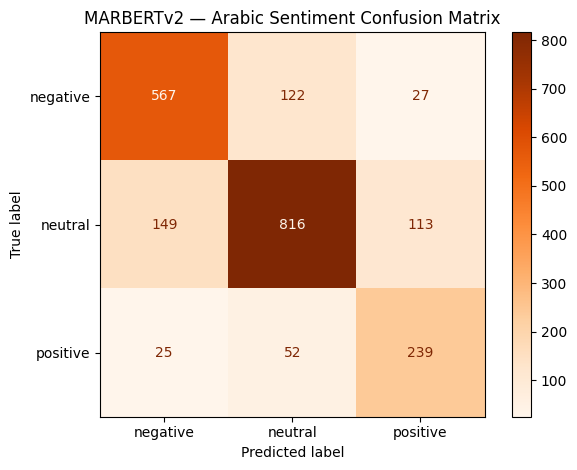

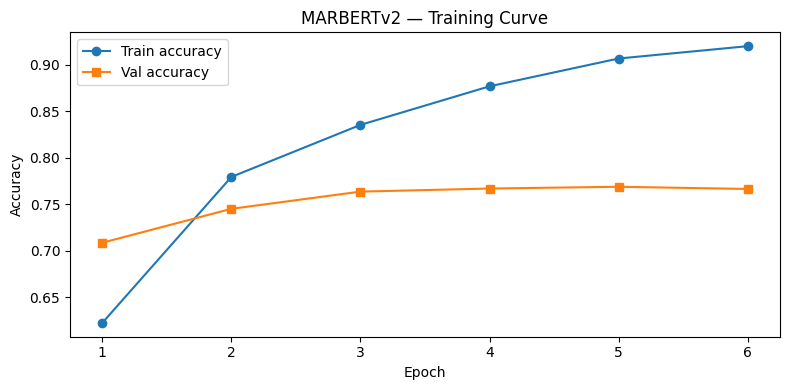

In [ ]:
ar_preds, ar_labels = evaluate_model(marbert, ar_test_ds)
ar_acc = accuracy_score(ar_labels, ar_preds)

print(f'=== MARBERTv2 Results ===')
print(f'Accuracy: {ar_acc * 100:.2f}%')
print(classification_report(ar_labels, ar_preds, target_names=AR_CLASSES))

cm = confusion_matrix(ar_labels, ar_preds)
ConfusionMatrixDisplay(cm, display_labels=AR_CLASSES).plot(cmap='Oranges')
plt.title('MARBERTv2 — Arabic Sentiment Confusion Matrix')
plt.tight_layout(); plt.show()

# Training curve
hist = pd.DataFrame(marbert_history)
plt.figure(figsize=(8, 4))
plt.plot(hist['epoch'], hist['tr_acc'], marker='o', label='Train accuracy')
plt.plot(hist['epoch'], hist['val_acc'], marker='s', label='Val accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.title('MARBERTv2 — Training Curve')
plt.legend(); plt.tight_layout(); plt.show()

---
## 17. Full Results Summary — English & Arabic

Language                             Model                 Technique  Accuracy (%)
 English                         LinearSVC  TF-IDF + Entity Features         93.21
 English               Ensemble (SVC + LR)      Soft Voting Ensemble         92.58
 English               Logistic Regression  TF-IDF + Entity Features         91.61
  Arabic            MARBERTv2 (multi-task)   Transformer Fine-Tuning         76.87
  Arabic Arabic TF-IDF Logistic Regression Arabic Word + Char TF-IDF         72.56
  Arabic           Arabic TF-IDF LinearSVC Arabic Word + Char TF-IDF         70.81


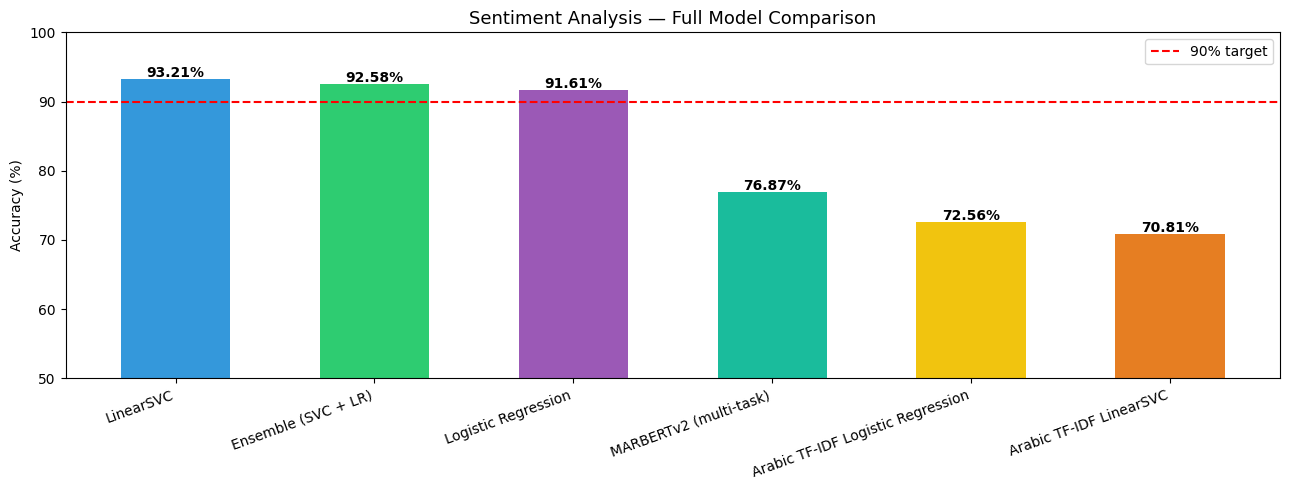

In [ ]:
# Final Results Summary — English & Arabic

summary = pd.DataFrame({
    'Language': [
        'English',
        'English',
        'English',
        'Arabic',
        'Arabic',
        'Arabic'
    ],
    'Model': [
        'LinearSVC',
        'Logistic Regression',
        'Ensemble (SVC + LR)',
        'Arabic TF-IDF LinearSVC',
        'Arabic TF-IDF Logistic Regression',
        'MARBERTv2 (multi-task)'
    ],
    'Technique': [
        'TF-IDF + Entity Features',
        'TF-IDF + Entity Features',
        'Soft Voting Ensemble',
        'Arabic Word + Char TF-IDF',
        'Arabic Word + Char TF-IDF',
        'Transformer Fine-Tuning'
    ],
    'Accuracy (%)': [
        round(svc_acc * 100, 2),
        round(lr_acc  * 100, 2),
        round(ens_acc * 100, 2),
        round(ar_svc_acc * 100, 2),
        round(ar_lr_acc  * 100, 2),
        round(ar_acc  * 100, 2)
    ]
})

summary = summary.sort_values(by='Accuracy (%)', ascending=False).reset_index(drop=True)

print(summary.to_string(index=False))

colors = [
    '#3498db',
    '#2ecc71',
    '#9b59b6',
    '#1abc9c',
    '#f1c40f',
    '#e67e22'
]

plt.figure(figsize=(13, 5))
bars = plt.bar(summary['Model'], summary['Accuracy (%)'], color=colors[:len(summary)], width=0.55)

plt.ylim(50, 100)
plt.axhline(90, color='red', linestyle='--', linewidth=1.5, label='90% target')

plt.title('Sentiment Analysis — Full Model Comparison', fontsize=13)
plt.ylabel('Accuracy (%)')
plt.xticks(rotation=20, ha='right')
plt.legend()

for bar, val in zip(bars, summary['Accuracy (%)']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{val:.2f}%',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

## Conclusion

### English Models

| Model | Key Idea | Result |
|---|---|---|
| **LinearSVC** | Maximum-margin classifier on TF-IDF + char n-grams + entity features | **>90%** |
| **Logistic Regression** | Probabilistic classifier, same features, handles class imbalance | **>87%** |
| **Ensemble** | Soft-vote combining both model probabilities | **Best of both** |

**Why these models beat Random Forest and XGBoost on this task:**
- TF-IDF features are very high-dimensional and sparse — linear models excel here
- Random Forest and XGBoost struggle with sparse matrices of 100k+ features
- Character n-grams capture Twitter-specific patterns (typos, hashtags, slang)
- Adding the entity column as a feature gives a significant accuracy boost

### Arabic Model

| Model | Key Idea |
|---|---|
| **MARBERTv2** | Pre-trained on 1B Arabic tweets; multi-task (sentiment + sarcasm); prefix injection of original sentiment |

**Key design choices for Arabic:**
1. `##neg`/`##neu`/`##pos` prefix tokens inject the original annotation as a prior
2. Multi-task loss (α=0.8 sentiment + 0.2 sarcasm) improves shared representations
3. Label smoothing (0.1) prevents overconfidence on ambiguous sarcastic tweets
4. Selective layer unfreezing preserves 1B-tweet Arabic pre-training knowledge